In [1]:
# ============================================
# Startup Cell: Mount Drive + Load Config + Verify Inputs
# ============================================

from google.colab import drive
drive.mount("/content/drive")

import os
import sys

# -------------------------------------------------
# Add project src directory to Python path
# -------------------------------------------------
PROJECT_SRC_PATH = "/content/drive/MyDrive/DIP_Project/src"

if PROJECT_SRC_PATH not in sys.path:
    sys.path.append(PROJECT_SRC_PATH)

# -------------------------------------------------
# Import project configuration
# -------------------------------------------------
from project_config import *

print("Project configuration loaded successfully.")

# -------------------------------------------------
# Construct required file paths using config
# -------------------------------------------------
TEST_FEATURES_PATH = os.path.join(METADATA_DIR, TEST_NORMALIZED_FILENAME)
SCALER_PATH = os.path.join(MODELS_DIR, SCALER_FILENAME)

# NOTE:
# Final model filename is not explicitly defined in config,
# so we dynamically detect it
MODEL_FILES = [
    f for f in os.listdir(MODELS_DIR)
    if f.endswith(".pkl") and "model" in f
]

# -------------------------------------------------
# Verify required input files
# -------------------------------------------------
print("\nVerifying required input files...\n")

all_ok = True

# Check test features
if os.path.exists(TEST_FEATURES_PATH):
    print(f"{TEST_FEATURES_PATH}  --> OK")
else:
    print(f"{TEST_FEATURES_PATH}  --> MISSING")
    all_ok = False

# Check scaler
if os.path.exists(SCALER_PATH):
    print(f"{SCALER_PATH}  --> OK")
else:
    print(f"{SCALER_PATH}  --> MISSING")
    all_ok = False

# Check model(s)
if len(MODEL_FILES) > 0:
    print("\nDetected model file(s):")
    for m in MODEL_FILES:
        print(f"{os.path.join(MODELS_DIR, m)}  --> OK")
else:
    print(f"{MODELS_DIR}  --> NO MODEL FILES FOUND")
    all_ok = False

# -------------------------------------------------
# Final status
# -------------------------------------------------
if all_ok:
    print("\nAll required files are present. Ready to proceed.")
else:
    raise FileNotFoundError("\nOne or more required files are missing. Please check paths.")



Mounted at /content/drive
Project configuration loaded successfully.

Verifying required input files...

/content/drive/MyDrive/DIP_Project/data/metadata/test_feature_vectors_normalized.csv  --> OK
/content/drive/MyDrive/DIP_Project/models/scaler.pkl  --> OK

Detected model file(s):
/content/drive/MyDrive/DIP_Project/models/final_rbf_svm_model.pkl  --> OK

All required files are present. Ready to proceed.


In [2]:
# ============================================================
# Cell 0: Notebook Overview
# ============================================================
#
# Purpose:
# Evaluate the final trained classifier on the independent
# held-out test set using the normalized Digital Image
# Processing (DIP) feature vectors generated in earlier
# pipeline steps.
#
# This notebook provides the final unbiased assessment of
# classifier performance after model selection and training
# have already been completed. It uses the saved final model
# from Notebook 08 and applies it to the test set exactly
# once to measure generalization performance.
#
# ------------------------------------------------------------
# Inputs:
# ------------------------------------------------------------
# Normalized training and test datasets produced in
# Notebook 06:
#
#   - X_train
#   - y_train
#   - X_test
#   - y_test
#
# Saved model artifacts produced in Notebook 08:
#
#   - final trained classifier (.pkl)
#   - scaler.pkl
#   - best_model_config.json
#   - cross_validation_results.csv
#
# These datasets:
#   - contain the full DIP feature vectors (25 features)
#   - are normalized using training-set statistics
#   - are free of missing values
#
# ------------------------------------------------------------
# Assumptions:
# ------------------------------------------------------------
# - Feature extraction and normalization have been completed
# - Model selection and cross-validation have already been
#   completed in Notebook 08
# - The dataset is split into training and test sets only
# - The saved model is the final selected classifier
# - The test set has not been used for model selection or
#   tuning
#
# ------------------------------------------------------------
# Cell-by-Cell Flow:
# ------------------------------------------------------------
# Cell 1:
#   Environment setup and imports
#
# Cell 2:
#   Load normalized test data and saved model artifacts
#
# Cell 3:
#   Run sanity checks on loaded data and separate features
#   and labels
#
# Cell 4:
#   Generate class predictions and class probabilities for
#   the test set
#
# Cell 5:
#   Compute final evaluation metrics
#
# Cell 6:
#   Generate and display the confusion matrix
#
# Cell 7:
#   Generate and display the ROC curve
#
# Cell 8:
#   Summarize final test results in tabular form
#
# Cell 9:
#   Save final evaluation outputs for documentation and
#   reporting
#
# ------------------------------------------------------------
# Outputs:
# ------------------------------------------------------------
# - Final test-set accuracy, precision, recall, F1-score,
#   and ROC-AUC
# - Confusion matrix
# - ROC curve
# - Summary table of final evaluation results
# - Saved evaluation outputs for reporting and project
#   documentation
#
# ------------------------------------------------------------
# Notes:
# ------------------------------------------------------------
# - This notebook performs the final independent evaluation
#   on the held-out test set
# - No model tuning or selection is performed in this notebook
# - Test results from this notebook should be treated as the
#   final performance results of the classifier
#
# ============================================================

print("Notebook overview loaded.")


Notebook overview loaded.


In [3]:
# ============================================================
# Cell 1: Imports and Environment Setup
# ============================================================

# ------------------------------------------------------------
# Standard libraries
# ------------------------------------------------------------
import os
import json
import pickle
import numpy as np
import pandas as pd
import joblib

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Sklearn metrics
# ------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# ------------------------------------------------------------
# Paths (constructed from config)
# ------------------------------------------------------------
TEST_FEATURES_PATH = os.path.join(METADATA_DIR, TEST_NORMALIZED_FILENAME)
SCALER_PATH = os.path.join(MODELS_DIR, SCALER_FILENAME)

# Model file will be detected dynamically later
MODEL_PATH = None

# ------------------------------------------------------------
# Column definitions
# ------------------------------------------------------------
METADATA_COLS = METADATA_COLUMNS
FEATURE_COLS = None

# ------------------------------------------------------------
# Class label definitions
# ------------------------------------------------------------
CLASS_LABELS = VALID_LABELS
POSITIVE_CLASS = AI_LABEL

# ------------------------------------------------------------
# Visualization settings
# ------------------------------------------------------------
sns.set(style="whitegrid")

print("Imports and environment setup complete.")



Imports and environment setup complete.


In [4]:
# ============================================================
# Cell 2: Load Test Data and Saved Model Artifacts
# ============================================================

# ------------------------------------------------------------
# Load normalized test dataset
# ------------------------------------------------------------
df_test = pd.read_csv(TEST_FEATURES_PATH)

print("Normalized test dataset loaded successfully.")
print(f"Test data shape: {df_test.shape}")

# ------------------------------------------------------------
# Identify metadata and feature columns
# ------------------------------------------------------------
FEATURE_COLS = [col for col in df_test.columns if col not in METADATA_COLS]

print(f"\nMetadata columns ({len(METADATA_COLS)}): {METADATA_COLS}")
print(f"Feature columns ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

# ------------------------------------------------------------
# Verify expected feature count
# ------------------------------------------------------------
if len(FEATURE_COLS) != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} feature columns, "
        f"but found {len(FEATURE_COLS)}."
    )

print(f"\nFeature count check passed: {len(FEATURE_COLS)} features found.")

# ------------------------------------------------------------
# Detect saved final model file
# ------------------------------------------------------------
model_candidates = [
    f for f in os.listdir(MODELS_DIR)
    if f.endswith(".pkl") and "model" in f.lower()
]

if len(model_candidates) == 0:
    raise FileNotFoundError(
        f"No saved model file was found in: {MODELS_DIR}"
    )

if len(model_candidates) > 1:
    print("\nMultiple model files detected:")
    for fname in model_candidates:
        print(f" - {fname}")
    raise ValueError(
        "Multiple candidate model files found. Please keep only the "
        "intended final model in MODELS_DIR or revise selection logic."
    )

MODEL_PATH = os.path.join(MODELS_DIR, model_candidates[0])

# ------------------------------------------------------------
# Load final model
# ------------------------------------------------------------
try:
    with open(MODEL_PATH, "rb") as f:
        model = pickle.load(f)
except Exception:
    model = joblib.load(MODEL_PATH)

print(f"\nFinal model loaded successfully: {model_candidates[0]}")

# ------------------------------------------------------------
# Load optional saved artifacts if present
# ------------------------------------------------------------
BEST_MODEL_CONFIG_PATH = os.path.join(MODELS_DIR, BEST_MODEL_CONFIG_FILENAME)
CV_RESULTS_PATH_MODELS = os.path.join(MODELS_DIR, CV_RESULTS_FILENAME)
CV_RESULTS_PATH_METADATA = os.path.join(METADATA_DIR, CV_RESULTS_FILENAME)

best_model_config = None
df_cv_results = None

if os.path.exists(BEST_MODEL_CONFIG_PATH):
    with open(BEST_MODEL_CONFIG_PATH, "r") as f:
        best_model_config = json.load(f)
    print("Best model configuration loaded successfully.")
else:
    print("Best model configuration file not found. Continuing without it.")

if os.path.exists(CV_RESULTS_PATH_MODELS):
    df_cv_results = pd.read_csv(CV_RESULTS_PATH_MODELS)
    print(f"Cross-validation results loaded successfully: {CV_RESULTS_PATH_MODELS}")
elif os.path.exists(CV_RESULTS_PATH_METADATA):
    df_cv_results = pd.read_csv(CV_RESULTS_PATH_METADATA)
    print(f"Cross-validation results loaded successfully: {CV_RESULTS_PATH_METADATA}")
else:
    print("Cross-validation results file not found. Continuing without it.")


Normalized test dataset loaded successfully.
Test data shape: (3600, 29)

Metadata columns (4): ['filename', 'class_label', 'source_dataset', 'subset']
Feature columns (25):
['Mean Gradient', 'Std Gradient', 'Max Gradient', 'Gradient Entropy', 'Edge Density', 'Orientation Mean', 'Orientation Std', 'Orientation Entropy', 'Global Entropy', 'Local Entropy Mean', 'Local Entropy Std', 'Intensity Mean', 'Intensity Std', 'Laplacian Variance', 'Patch Variance Mean', 'Patch Variance Std', 'Noise Residual Energy', 'Low Frequency Energy Ratio', 'High Frequency Energy Ratio', 'Radial Mean', 'Radial Std', 'Radial Entropy', 'Spectral Centroid', 'Spectral Bandwidth', 'Log Spectrum Std']

Feature count check passed: 25 features found.

Final model loaded successfully: final_rbf_svm_model.pkl
Best model configuration loaded successfully.
Cross-validation results loaded successfully: /content/drive/MyDrive/DIP_Project/data/metadata/cross_validation_results.csv


In [5]:
# ============================================================
# Cell 3: Run Sanity Checks and Separate Features and Labels
# ============================================================

# ------------------------------------------------------------
# Verify required columns are present
# ------------------------------------------------------------
missing_metadata_cols = [col for col in METADATA_COLS if col not in df_test.columns]

if missing_metadata_cols:
    raise ValueError(
        f"Missing required metadata columns: {missing_metadata_cols}"
    )

if len(FEATURE_COLS) != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} feature columns, but found {len(FEATURE_COLS)}."
    )

print("Required column check passed.")

# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------
total_missing = df_test.isnull().sum().sum()

if total_missing > 0:
    raise ValueError(f"Test dataset contains {total_missing} missing value(s).")

print("Missing value check passed.")

# ------------------------------------------------------------
# Verify class labels
# ------------------------------------------------------------
invalid_labels = sorted(set(df_test["class_label"]) - set(CLASS_LABELS))

if invalid_labels:
    raise ValueError(
        f"Unexpected class labels found: {invalid_labels}"
    )

print("Class label check passed.")

# ------------------------------------------------------------
# Verify subset column
# ------------------------------------------------------------
invalid_subsets = sorted(set(df_test["subset"]) - {TEST_SUBSET})

if invalid_subsets:
    raise ValueError(
        f"Unexpected subset values found in test data: {invalid_subsets}"
    )

print("Subset check passed.")

# ------------------------------------------------------------
# Separate features and labels
# ------------------------------------------------------------
X_test = df_test[FEATURE_COLS].copy()
y_test = df_test["class_label"].copy()

print("\nSeparated feature matrix and label vector successfully.")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# ------------------------------------------------------------
# Encode labels for ROC-AUC and related metrics
# ------------------------------------------------------------
y_test_binary = (y_test == POSITIVE_CLASS).astype(int)

print(f"\nPositive class for evaluation: '{POSITIVE_CLASS}'")
print("Binary label encoding created successfully.")

# ------------------------------------------------------------
# Display class distribution
# ------------------------------------------------------------
class_counts = y_test.value_counts().sort_index()

print("\nTest set class distribution:")
for label, count in class_counts.items():
    print(f"  {label}: {count}")

# ------------------------------------------------------------
# Display first few rows for verification
# ------------------------------------------------------------
print("\nFirst 5 rows of X_test:")
print(X_test.head())

print("\nFirst 10 labels in y_test:")
print(y_test.head(10).to_list())

print("\nFirst 10 labels in y_test_binary:")
print(y_test_binary.head(10).to_list())



Required column check passed.
Missing value check passed.
Class label check passed.
Subset check passed.

Separated feature matrix and label vector successfully.
X_test shape: (3600, 25)
y_test shape: (3600,)

Positive class for evaluation: 'ai'
Binary label encoding created successfully.

Test set class distribution:
  ai: 1800
  rl: 1800

First 5 rows of X_test:
   Mean Gradient  Std Gradient  Max Gradient  Gradient Entropy  Edge Density  Orientation Mean  Orientation Std  \
0       0.497872     -0.409551      0.681864          0.559988      0.054908         -0.305565         0.885148   
1       0.927560      0.358681      0.946748          0.880741      0.393183         -0.422829         0.274049   
2      -0.620579      0.043886      1.061698         -1.269570     -0.505036         -0.727340         1.345230   
3       0.403077     -0.557194     -1.870341          1.648585      1.121353          1.184433         1.068629   
4      -0.126248      0.518973      0.726811         -0.54

In [6]:
# ============================================================
# Cell 4: Generate Test-Set Predictions and Probabilities
# ============================================================

# ------------------------------------------------------------
# Generate predicted class labels
# ------------------------------------------------------------
y_pred = model.predict(X_test)

print("Predicted class labels generated successfully.")
print(f"Number of predictions: {len(y_pred)}")

# ------------------------------------------------------------
# Generate class probabilities
# ------------------------------------------------------------
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)
    print("Predicted class probabilities generated successfully.")
else:
    raise AttributeError(
        "The loaded model does not support predict_proba(). "
        "Ensure probability=True was enabled when training the RBF SVM."
    )

# ------------------------------------------------------------
# Identify probability column for positive class
# ------------------------------------------------------------
if not hasattr(model, "classes_"):
    raise AttributeError(
        "The loaded model does not expose classes_. "
        "Cannot determine positive-class probability column."
    )

class_order = list(model.classes_)

if POSITIVE_CLASS not in class_order:
    raise ValueError(
        f"Positive class '{POSITIVE_CLASS}' not found in model.classes_: {class_order}"
    )

positive_class_index = class_order.index(POSITIVE_CLASS)
y_score = y_proba[:, positive_class_index]

print(f"\nModel class order: {class_order}")
print(f"Positive class index: {positive_class_index}")
print(f"Positive class for scoring: '{POSITIVE_CLASS}'")

# ------------------------------------------------------------
# Basic output checks
# ------------------------------------------------------------
if len(y_pred) != len(y_test):
    raise ValueError(
        f"Prediction length mismatch: len(y_pred)={len(y_pred)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_score) != len(y_test):
    raise ValueError(
        f"Score length mismatch: len(y_score)={len(y_score)} "
        f"but len(y_test)={len(y_test)}"
    )

print("\nPrediction length checks passed.")

# ------------------------------------------------------------
# Preview outputs
# ------------------------------------------------------------
print("\nFirst 10 predicted labels:")
print(y_pred[:10].tolist())

print("\nFirst 10 positive-class probabilities:")
print(np.round(y_score[:10], 6).tolist())



Predicted class labels generated successfully.
Number of predictions: 3600
Predicted class probabilities generated successfully.

Model class order: ['ai', 'rl']
Positive class index: 0
Positive class for scoring: 'ai'

Prediction length checks passed.

First 10 predicted labels:
['rl', 'rl', 'ai', 'ai', 'rl', 'ai', 'rl', 'rl', 'rl', 'rl']

First 10 positive-class probabilities:
[0.189129, 0.0792, 0.533673, 0.997569, 0.084119, 0.808094, 0.084162, 0.398735, 0.475256, 0.242723]


In [7]:
# ============================================================
# Cell 5: Compute Final Evaluation Metrics
# ============================================================

# ------------------------------------------------------------
# Compute classification metrics
# ------------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=POSITIVE_CLASS
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=POSITIVE_CLASS
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=POSITIVE_CLASS
)

roc_auc = roc_auc_score(y_test_binary, y_score)

# ------------------------------------------------------------
# Display final metric values
# ------------------------------------------------------------
print("Final test-set evaluation metrics:\n")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# ------------------------------------------------------------
# Store metrics in a dictionary for later use
# ------------------------------------------------------------
final_metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "roc_auc": roc_auc
}



Final test-set evaluation metrics:

Accuracy : 0.7894
Precision: 0.7944
Recall   : 0.7811
F1-score : 0.7877
ROC-AUC  : 0.8699


Confusion matrix computed successfully.

Confusion Matrix (counts):
            Predicted: ai  Predicted: rl
Actual: ai           1406            394
Actual: rl            364           1436


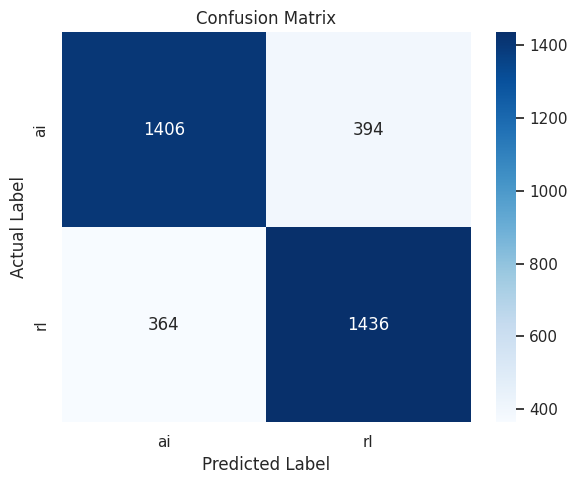


Confusion Matrix (normalized by actual class):
            Predicted: ai  Predicted: rl
Actual: ai         0.7811         0.2189
Actual: rl         0.2022         0.7978


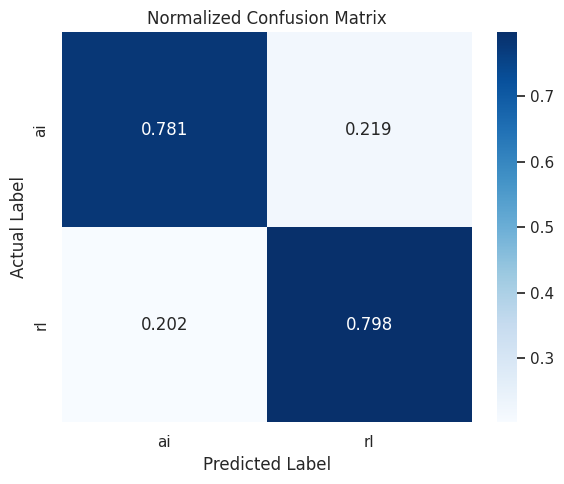

In [8]:
# ============================================================
# Cell 6: Generate and Display Confusion Matrix
# ============================================================

# ------------------------------------------------------------
# Compute confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=CLASS_LABELS
)

print("Confusion matrix computed successfully.\n")

# ------------------------------------------------------------
# Display confusion matrix (raw values)
# ------------------------------------------------------------
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual: {label}" for label in CLASS_LABELS],
    columns=[f"Predicted: {label}" for label in CLASS_LABELS]
)

print("Confusion Matrix (counts):")
print(cm_df)

# ------------------------------------------------------------
# Plot confusion matrix (heatmap)
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Compute normalized confusion matrix (row-wise)
# ------------------------------------------------------------
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

cm_norm_df = pd.DataFrame(
    cm_normalized,
    index=[f"Actual: {label}" for label in CLASS_LABELS],
    columns=[f"Predicted: {label}" for label in CLASS_LABELS]
)

print("\nConfusion Matrix (normalized by actual class):")
print(cm_norm_df.round(4))

# ------------------------------------------------------------
# Plot normalized confusion matrix
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


ROC curve computed successfully.
Number of ROC points: 1055


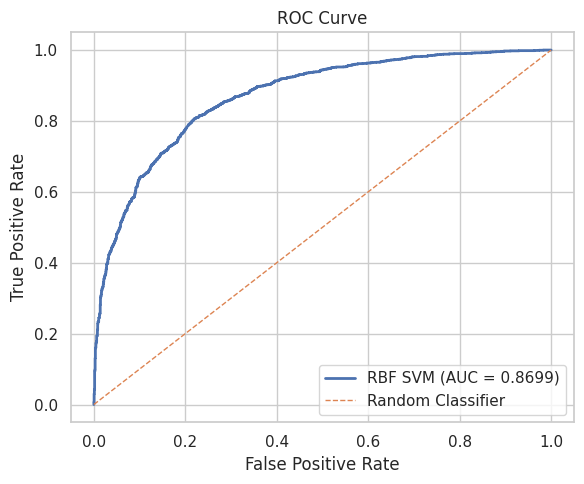


First 10 ROC points:
   threshold       fpr       tpr
0        inf  0.000000  0.000000
1   0.999995  0.000000  0.000556
2   0.997994  0.000000  0.006111
3   0.997870  0.000556  0.006111
4   0.989550  0.000556  0.030556
5   0.989269  0.001111  0.030556
6   0.985771  0.001111  0.041667
7   0.985731  0.001667  0.041667
8   0.967479  0.001667  0.093333
9   0.967277  0.002222  0.093333


In [9]:
# ============================================================
# Cell 7: Generate and Display ROC Curve
# ============================================================

# ------------------------------------------------------------
# Compute ROC curve
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)

print("ROC curve computed successfully.")
print(f"Number of ROC points: {len(fpr)}")

# ------------------------------------------------------------
# Plot ROC curve
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"RBF SVM (AUC = {roc_auc:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Preview first few ROC points
# ------------------------------------------------------------
roc_preview = pd.DataFrame({
    "threshold": thresholds[:10],
    "fpr": fpr[:10],
    "tpr": tpr[:10]
})

print("\nFirst 10 ROC points:")
print(roc_preview.round(6))



In [10]:
# ============================================================
# Cell 8: Summarize Final Test Results in Tabular Form
# ============================================================

# ------------------------------------------------------------
# Create final results summary table
# ------------------------------------------------------------
df_final_results = pd.DataFrame([
    {
        "model_name": os.path.basename(MODEL_PATH),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    }
])

print("Final test-results summary table:\n")
print(df_final_results.round(4))

# ------------------------------------------------------------
# Create report-friendly transposed summary
# ------------------------------------------------------------
df_final_results_transposed = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "value": [accuracy, precision, recall, f1, roc_auc]
})

print("\nTransposed metric summary:\n")
print(df_final_results_transposed.round(4))

# ------------------------------------------------------------
# Optional: include best model configuration if available
# ------------------------------------------------------------
if best_model_config is not None:
    print("\nBest model configuration used for final evaluation:\n")
    print(json.dumps(best_model_config, indent=4))
else:
    print("\nBest model configuration not available.")



Final test-results summary table:

                model_name  accuracy  precision  recall  f1_score  roc_auc
0  final_rbf_svm_model.pkl    0.7894     0.7944  0.7811    0.7877   0.8699

Transposed metric summary:

      metric   value
0   Accuracy  0.7894
1  Precision  0.7944
2     Recall  0.7811
3   F1-score  0.7877
4    ROC-AUC  0.8699

Best model configuration used for final evaluation:

{
    "model_name": "RBF_SVM_C100_gamma0.01",
    "model_type": "RBF SVM",
    "hyperparameters": {
        "C": 100.0,
        "gamma": 0.01,
        "kernel": "rbf",
        "probability": true,
        "random_state": 42
    },
    "num_features": 25,
    "k_folds": 5,
    "train_samples": 14400,
    "test_samples": 3600
}


In [11]:
# ============================================================
# Cell 9: Save Final Evaluation Outputs
# ============================================================

# ------------------------------------------------------------
# Define output file paths
# ------------------------------------------------------------
FINAL_RESULTS_CSV_PATH = os.path.join(METADATA_DIR, FINAL_RESULTS_FILENAME)
FINAL_RESULTS_JSON_PATH = os.path.join(METADATA_DIR, FINAL_RESULTS_JSON_FILENAME)
CONFUSION_MATRIX_CSV_PATH = os.path.join(METADATA_DIR, CONFUSION_MATRIX_FILENAME)
ROC_POINTS_CSV_PATH = os.path.join(METADATA_DIR, ROC_POINTS_FILENAME)

# ------------------------------------------------------------
# Save final metric summary table
# ------------------------------------------------------------
df_final_results.to_csv(FINAL_RESULTS_CSV_PATH, index=False)
print(f"Saved final results CSV: {FINAL_RESULTS_CSV_PATH}")

# ------------------------------------------------------------
# Save final metrics dictionary as JSON
# ------------------------------------------------------------
with open(FINAL_RESULTS_JSON_PATH, "w") as f:
    json.dump(final_metrics, f, indent=4)

print(f"Saved final results JSON: {FINAL_RESULTS_JSON_PATH}")

# ------------------------------------------------------------
# Save confusion matrix table
# ------------------------------------------------------------
cm_df.to_csv(CONFUSION_MATRIX_CSV_PATH)
print(f"Saved confusion matrix CSV: {CONFUSION_MATRIX_CSV_PATH}")

# ------------------------------------------------------------
# Save ROC curve points
# ------------------------------------------------------------
df_roc_points = pd.DataFrame({
    "threshold": thresholds,
    "fpr": fpr,
    "tpr": tpr
})

df_roc_points.to_csv(ROC_POINTS_CSV_PATH, index=False)
print(f"Saved ROC curve points CSV: {ROC_POINTS_CSV_PATH}")



Saved final results CSV: /content/drive/MyDrive/DIP_Project/data/metadata/final_test_results.csv
Saved final results JSON: /content/drive/MyDrive/DIP_Project/data/metadata/final_test_results.json
Saved confusion matrix CSV: /content/drive/MyDrive/DIP_Project/data/metadata/final_confusion_matrix.csv
Saved ROC curve points CSV: /content/drive/MyDrive/DIP_Project/data/metadata/final_roc_curve_points.csv
